In [4]:
print("Hello")

Hello


In [5]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

from dotenv import load_dotenv
load_dotenv()

True

In [6]:
import glob
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document
from langchain_google_genai import GoogleGenerativeAIEmbeddings

C:\Users\vaide\AppData\Local\Temp\ipykernel_8320\3958468047.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import FAISS


In [7]:
DOCS_DIR = "sample_docs"
INDEX_DIR = "faiss_index"

def load_and_split(docs_dir):
    chunks = []

    for path in glob.glob(os.path.join(docs_dir, "*.txt")):
        with open(path, "r", encoding = "utf-8") as f:
            text = f.read()
        source = os.path.basename(path)
        paragraphs = [p.strip() for p in text.split("\n\n") if p.strip()]

        current = ""
        for para in paragraphs:
            if  len(current) + len(para) + 2 <= 500:
                current = (current + "\n\n" + para).strip()
            else:
                if current:
                    chunks.append(Document(page_content = current, metadata = {"source": source}))
                current = para
        if current:
            chunks.append(Document(page_content = current, metadata = {"source": source}))
    return chunks

chunks = load_and_split(DOCS_DIR)
print(f"{len(chunks)} chunks ")


6 chunks 


In [8]:
# embeddings
#   embedding models convert words into numbers 

embeddings = GoogleGenerativeAIEmbeddings(model = "models/gemini-embedding-001")
vectorstore = FAISS.from_documents(chunks, embeddings)

# now save the embeddings locally
vectorstore.save_local(INDEX_DIR)
print(f"Index saved to {INDEX_DIR}/")

Index saved to faiss_index/


In [9]:
from langchain_core.tools import tool

@tool
def add(a:int, b:int) -> int:
    """ Adds a and b."""
    return a + b

@tool
def mutiply(a:int, b:int) -> int:
    """Multiplies a and b."""
    return a * b

@tool
def divide(a:int, b:int) -> float:
    """ Divides a by b."""
    return a / b

In [10]:
@tool
def search_docs(query: str) -> str:
    """ Search the knowledge base for information about AI/ ML concepts,
    Langgraph, RAG, embeddings, transformers, and related topics."""

    embeddings = GoogleGenerativeAIEmbeddings(model = "models/gemini-embedding-001")
    vectorstore = FAISS.load_local(INDEX_DIR, embeddings, allow_dangerous_deserialization = True)
    docs = vectorstore.as_retriever(search_kwargs = {"k": 3}).invoke(query)
    return "\n\n---\n\n".join(doc.page_content for doc in docs)

In [11]:
# so now that we have the tools we hve to write it in compiled form to let the model know what all tool it can use

tools = [add, mutiply, divide, search_docs]
tools_by_name = {t.name: t for t in tools}
print(tools_by_name)

{'add': StructuredTool(name='add', description='Adds a and b.', args_schema=<class 'langchain_core.utils.pydantic.add'>, func=<function add at 0x0000015D56E67060>), 'mutiply': StructuredTool(name='mutiply', description='Multiplies a and b.', args_schema=<class 'langchain_core.utils.pydantic.mutiply'>, func=<function mutiply at 0x0000015D56E67100>), 'divide': StructuredTool(name='divide', description='Divides a by b.', args_schema=<class 'langchain_core.utils.pydantic.divide'>, func=<function divide at 0x0000015D56E671A0>), 'search_docs': StructuredTool(name='search_docs', description='Search the knowledge base for information about AI/ ML concepts,\n   Langgraph, RAG, embeddings, transformers, and related topics.', args_schema=<class 'langchain_core.utils.pydantic.search_docs'>, func=<function search_docs at 0x0000015D56E67380>)}


In [12]:
# now that we have the tools and everything we will instantiate the model
from langchain_groq import ChatGroq

model = ChatGroq(model = "openai/gpt-oss-20b",temperature = 0)
model_with_tools = model.bind_tools(tools)

In [13]:
# now we have llm also now  we need to define the states of the langgraph
import operator
from typing import Annotated
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage

class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]
    llm_calls: int

In [14]:
from langchain_core.messages import SystemMessage, ToolMessage
def llm_call(state: MessagesState) -> dict :
    response = model_with_tools.invoke(
        [SystemMessage(content = (
            "You are a helpful assistant that can perform arithmetic "
            "and answer questions about AI/ ML concepts."
            "Use search_docs for  AI/ML questions, math tools for calculations. "
        ))] + state["messages"]
    )
    return{ 
         "messages" : [response],
         "llm_calls":  state.get("llm_calls",0) + 1,
    }

In [15]:
# tool message
def tool_node(state: MessagesState) -> dict:
    results = []

    for tool_call in state["messages"][-1].tool_calls:
        t = tools_by_name[tool_call["name"]]
        observation = t.invoke(tool_call["args"])
        results.append(ToolMessage(content = str(observation), tool_call_id = tool_call["id"]))
    return {"messages": results}

In [16]:
#  now we need a node that will let us decide should we continue to the next node or directly jump at the last node

from typing import Literal
from langgraph.graph import END

def should_continue(state: MessagesState) -> Literal["tool_node", "__end__"]:
    last = state["messages"][-1]

    if hasattr(last, "tool_calls") and last.tool_calls:
        return "tool_node"
    return END

In [17]:
# now we need to build the graph as everything else is done

from langgraph.graph import StateGraph, START, END

agent_builder = StateGraph(MessagesState)

agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("tool_node", tool_node)

# now add edges to connect the node together
agent_builder.add_edge(START, "llm_call")
# then add the conditional edge so as to choose different conditions when chosen a particular thing

agent_builder.add_conditional_edges("llm_call", should_continue, ["tool_node", END])
agent_builder.add_edge("tool_node", "llm_call")

#  now compile the graph together
agent = agent_builder.compile()

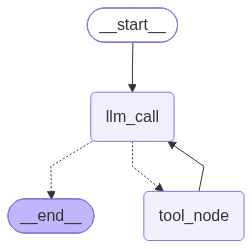

In [18]:
# now we will visualise the graph to check if it has turned out how we wanted
from IPython.display import Image, display
display(Image(agent.get_graph().draw_mermaid_png()))

In [19]:
# now we will run the langgraph
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage

def run_agent(question:str):
    print(f"Q : {question}")

    result = agent.invoke({"messages": [HumanMessage(content=question)], "llm_calls": 0})
    for msg in result["messages"]:
        if isinstance(msg, AIMessage) and msg.tool_calls:
            for tc in msg.tool_calls:
                print(f" tool: {tc['name']} args: {tc['args']}")
        if isinstance(msg, ToolMessage):
            print(f" result: {msg.content[:120]}")
    print(f"A: {result['messages'][-1].content}")
    print()

In [20]:
# now if we call this function we will get the answer
run_agent("What is 12 times 8?")

Q : What is 12 times 8?
 tool: mutiply args: {'a': 12, 'b': 8}
 result: 96
A: 12 × 8 = **96**



In [21]:
run_agent("What is LangGraph?")

Q : What is LangGraph?
 tool: search_docs args: {'query': 'LangGraph'}
 result: Quod equidem non reprehendo;
Lorem ipsum dolor sit amet, consectetur adipiscing elit. Quibus natura iure responderit non
A: **LangGraph** is a framework for building *stateful, graph‑oriented* applications that are powered by large language models (LLMs). It sits in the LangChain ecosystem but takes a different, more “workflow”‑centric approach than the classic “chain” pattern.

---

## 1.  What is a LangGraph?

| Feature | What it means | Why it matters |
|---------|---------------|----------------|
| **Graph‑based workflow** | You define nodes (functions, LLM calls, tools, etc.) and edges (transitions) that form a directed graph. | Makes complex, multi‑step logic easier to reason about and visualize. |
| **Stateful execution** | The graph keeps a mutable `state` object that flows through nodes. | Enables context‑aware decisions, memory, and incremental updates. |
| **Event‑driven** | Nodes can emit events